## Learning Goals

In this notebook we will learn:

- What is LangGraph?
- What is State?
- What is a Node?
- What is an Edge?
- How to build a simple graph
- How to compile a graph
- How to invoke a graph

Basic workflow:

START → Node → END

## 1. What is LangGraph?

LangGraph is a framework for building stateful, multi-step AI workflows as graphs.

The three most important concepts are:

**State + Nodes + Edges**

Think of a LangGraph workflow like a flowchart:

START
  ↓
Node A
  ↓
Node B
  ↓
END

- **State** → Data shared between nodes
- **Node** → A function that performs some work
- **Edge** → Defines where the workflow goes next

In [1]:
from typing import TypedDict

from langgraph.graph import StateGraph, START, END

## 2. Define the State

State is the shared information that flows through our graph.

For our first example, we only need one field:

In [2]:
class State(TypedDict):
    message: str

state: State = {
    "message": "Hi"
}

state

{'message': 'Hi'}

## 3. Create a Node

A node is simply a Python function.

The node receives the current state and returns updated state.

Our node will add a greeting to the existing message.

In [3]:
def greeting_node(state: State):
    print("Greeting node is running...")
    
    return {
        "message": state["message"] + " Hello from LangGraph!"
    }

### Test the Node Without LangGraph

Before putting the function into a graph, let's understand what it does.

Input:

```text
Hi

In [4]:
test_state: State = {
    "message": "Hi"
}

result = greeting_node(test_state)

result

Greeting node is running...


{'message': 'Hi Hello from LangGraph!'}

## 4. Build the Graph

Now we will create the actual LangGraph workflow.

Our workflow will be:

START
  ↓
greeting
  ↓
END

In [5]:
graph = StateGraph(State)
graph.add_node("greeting", greeting_node)

## 5. Add Edges

Now we need to tell LangGraph how the workflow should move.

First:

START → greeting

In [6]:
graph.add_edge(START, "greeting")
graph.add_edge("greeting", END)

## 6. Compile the Graph

Before we can execute the graph, we need to compile it.

In [7]:
app = graph.compile()

## 7. Invoke the Graph

Let's provide the initial state:

```python
{
    "message": "Hi"
}

In [8]:
result = app.invoke({
    "message": "Hi"
})

result

Greeting node is running...


{'message': 'Hi Hello from LangGraph!'}

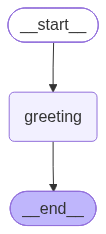

In [9]:
from IPython.display import Image, display

display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)

# Summary

We learned the basic LangGraph building blocks.

## State

Stores information shared between nodes.

```python
class State(TypedDict):
    message: str

def greeting_node(state):
    ...

graph.add_edge(START, "greeting")
graph.add_edge("greeting", END)

app = graph.compile()

app.invoke(...)